<a href="https://colab.research.google.com/github/vyasathul17/Machine-Learning/blob/main/LDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LDA



#Import Libraries

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Load Dataset

In [22]:
digits = load_digits()

In [23]:
x = digits.data
y = digits.target

# Train Test split

In [24]:
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size = 0.8,random_state = 42)

In [25]:
x_train.shape

(1437, 64)

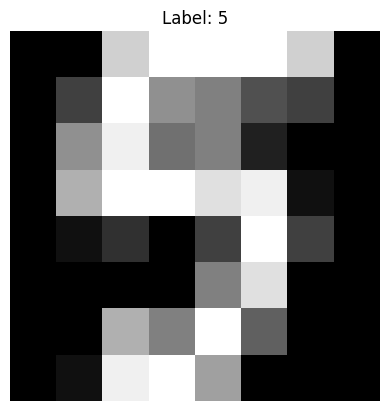

In [26]:
plt.imshow(x_train[5].reshape(8,8),cmap = "gray")
plt.title(f"Label: {y_train[5]}")
plt.axis("off")
plt.show()

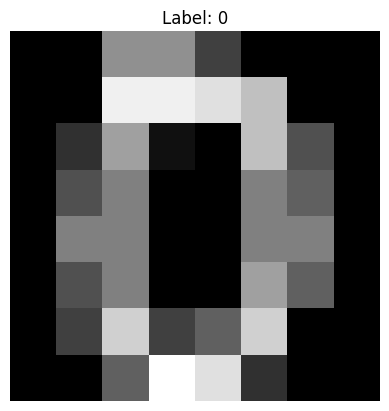

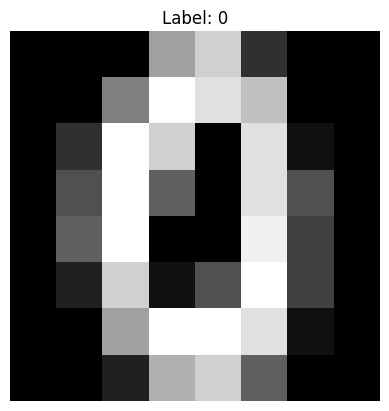

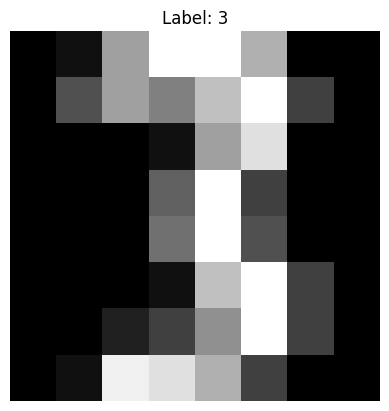

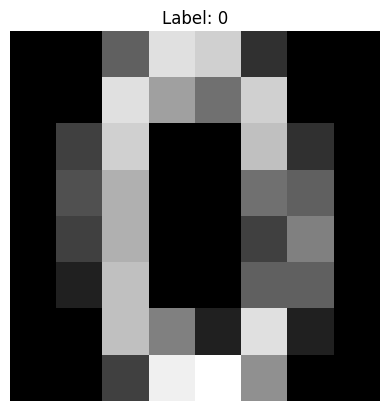

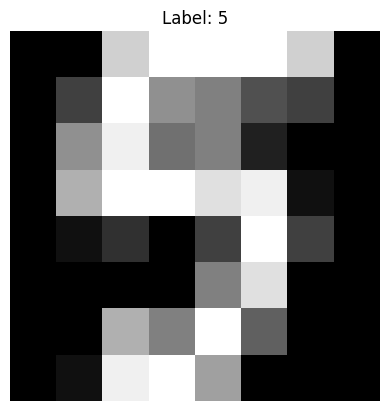

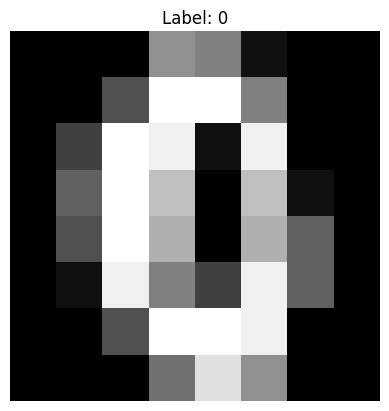

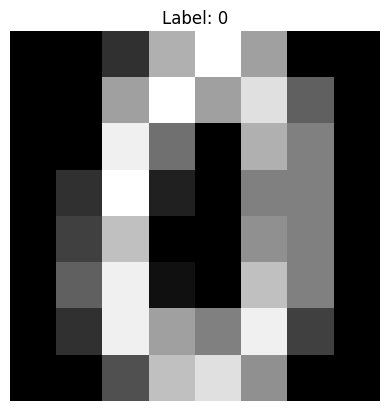

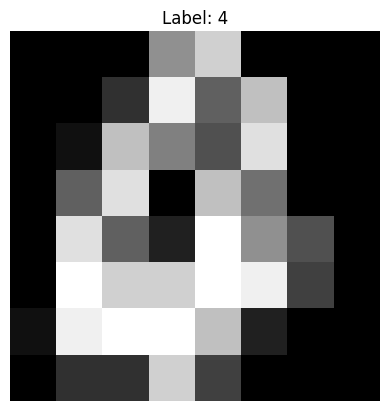

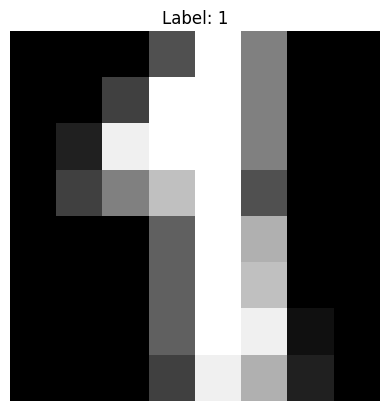

In [27]:
for i in range (1,10):
  plt.imshow(x_train[i].reshape(8,8),cmap = "gray")
  plt.title(f"Label: {y_train[i]}")
  plt.axis("off")
  plt.show()

# pipeline version

In [29]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
pipeline = Pipeline(
    steps = [
        ("scaler",StandardScaler()),
        ("LDA",LinearDiscriminantAnalysis(n_components = 9)),
        ("model",DecisionTreeClassifier())
    ]
)

pipeline.fit(x_train,y_train)
pred = pipeline.predict(x_test)


In [30]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

print("LDA Accuracy Score:",accuracy_score(y_test,pred))
print("\n classification Report:\n",classification_report(y_test,pred))

LDA Accuracy Score: 0.8916666666666667

 classification Report:
               precision    recall  f1-score   support

           0       1.00      0.94      0.97        33
           1       0.74      0.82      0.78        28
           2       0.94      0.88      0.91        33
           3       0.84      0.91      0.87        34
           4       0.94      0.96      0.95        46
           5       0.95      0.89      0.92        47
           6       1.00      0.97      0.99        35
           7       0.91      0.91      0.91        34
           8       0.75      0.80      0.77        30
           9       0.82      0.80      0.81        40

    accuracy                           0.89       360
   macro avg       0.89      0.89      0.89       360
weighted avg       0.90      0.89      0.89       360



#Confusion matrics visualization

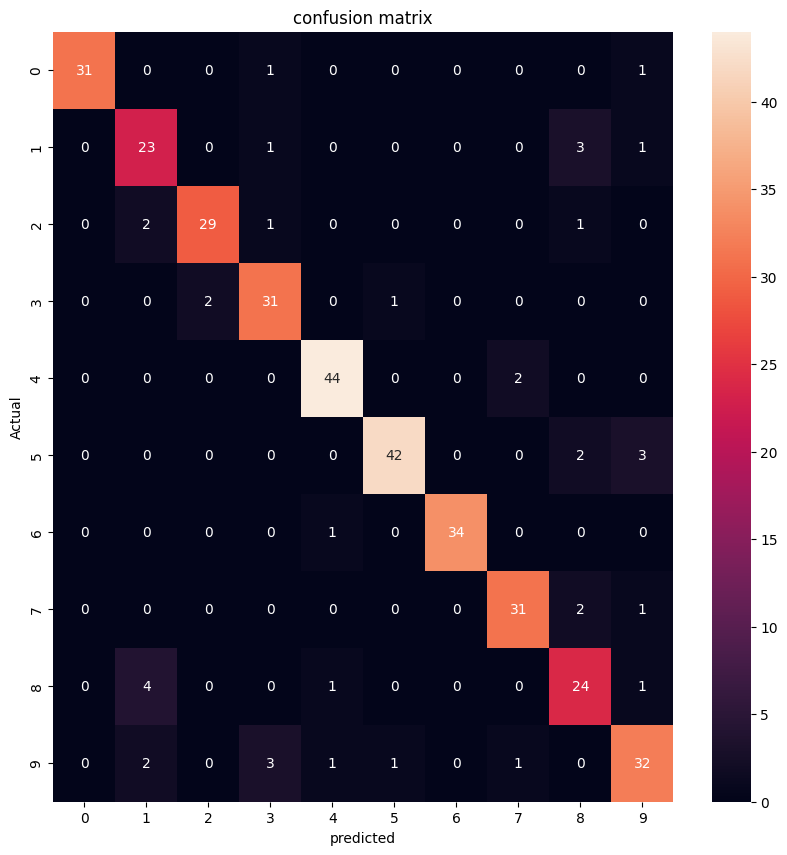

In [31]:
cm = confusion_matrix(y_test,pred)
plt.figure(figsize = (10,10))
sns.heatmap(cm,annot = True, fmt = "d")
plt.xlabel("predicted")
plt.ylabel("Actual")
plt.title("confusion matrix")
plt.show()

#Cross validation (check model stability)

In [32]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(pipeline,x_train,y_train,cv = 5)
print("cross-validation scores:",scores)
print("Mean cv accuracy:",scores.mean())

cross-validation scores: [0.88194444 0.85763889 0.85017422 0.90940767 0.87108014]
Mean cv accuracy: 0.8740490708478512


#Hyperparameter tuning

In [34]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__max_depth":[None,10,20],
    "model__min_samples_split":[2,5,10]
}

grid = GridSearchCV(estimator = pipeline,param_grid= param_grid,
                    cv = 3)
grid.fit(x_train,y_train)
print("Best params:",grid.best_params_)
print("Best score:",grid.best_score_)

Best params: {'model__max_depth': 20, 'model__min_samples_split': 2}
Best score: 0.8816979819067502


# compare with No LDA

In [36]:
pipeline_no_lda = Pipeline(
    steps = [
        ("scaler",StandardScaler()),
        ("model",DecisionTreeClassifier())
    ]
)

pipeline_no_lda.fit(x_train,y_train)
pred_no_lda = pipeline_no_lda.predict(x_test)

print("without LDA Accuracy:",accuracy_score(y_test,pred_no_lda))


print("with LDA accuracy:",accuracy_score(y_test,pred))

without LDA Accuracy: 0.8527777777777777
with LDA accuracy: 0.8916666666666667


#Visualization

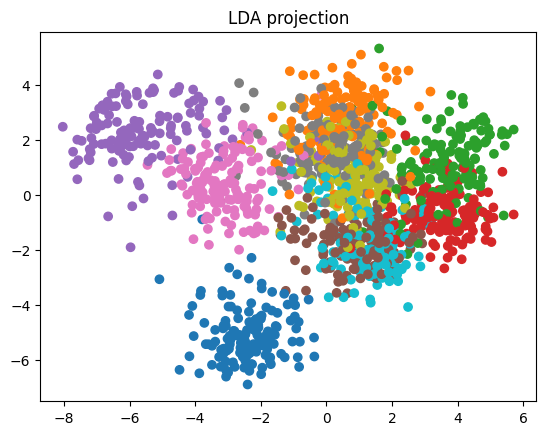

In [37]:
x_lda = pipeline.named_steps["LDA"].transform(
    pipeline.named_steps["scaler"].transform(x_train)
)

plt.scatter(x_lda[:,0],x_lda[:,1],c = y_train,cmap = "tab10")
plt.title("LDA projection")
plt.show()